<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [1]:
# Import Libraries (pandas, numpy, matplotlib)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



### Data

We will use retail data for time-series modeling. 

Link to the dataset:
 https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.



##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

_________________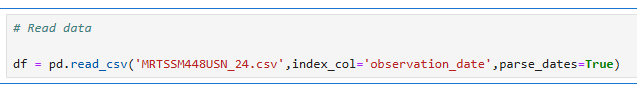

In [2]:
# Read data

df = pd.read_csv('MRTSSM448USN_24-1.csv', index_col='observation_date', parse_dates=True)

In [3]:
#pd.read_csv

In [4]:
# Print the first few rows of data
#d
df.head()

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


_______________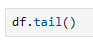

In [5]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [6]:
# Set name of column as 'Sales'. Use - df.columns 

# ...
df.columns = ['Sales']
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


Plot your data - Year vs Sales

hint: use df.plot  and plt.show()

____________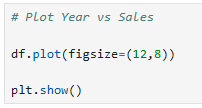

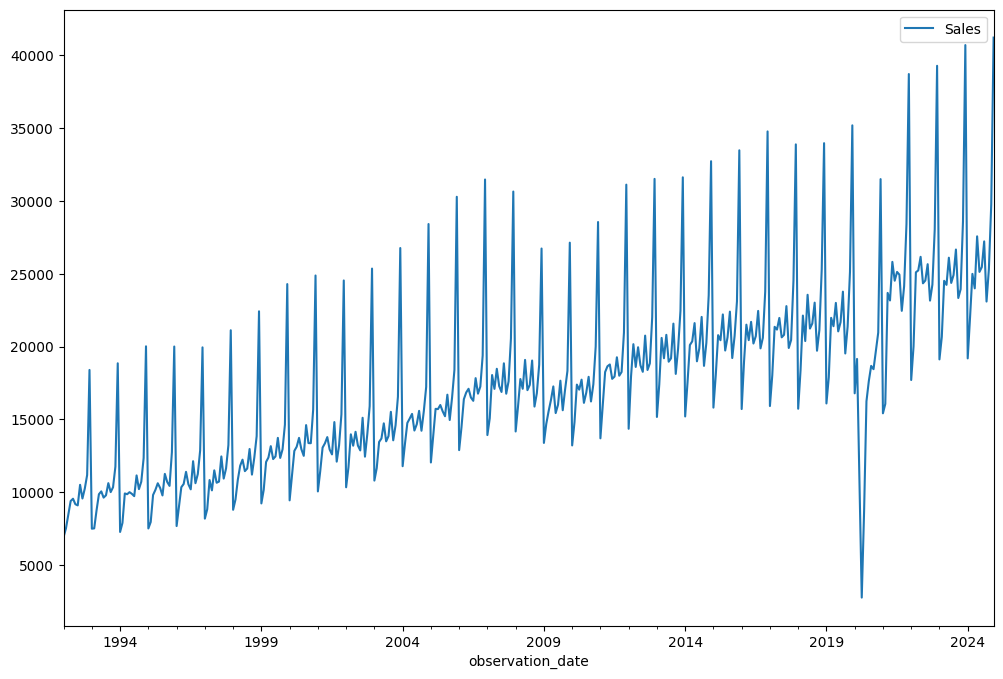

In [7]:
df.plot(figsize=(12,8))
plt.show()

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

______________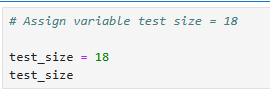

In [8]:
test_size =18
test_size

18

__________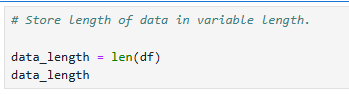

In [9]:
data_length = len(df)
data_length

396

__________________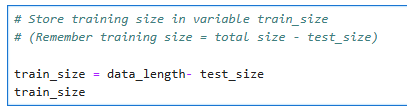

In [10]:
train_size = data_length - test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe.

____________________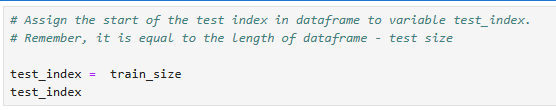

In [11]:
test_index = train_size
test_index

378

Next, we will separate train and test datasets.

_________________________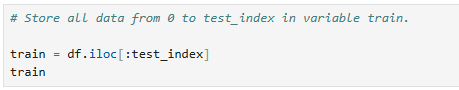

In [12]:
train = df.iloc[:test_index]
train

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [13]:
# Store everything from test_index to the last sample in the test variable 
# Hint - Use df.iloc

test = df.iloc[-test_size:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [14]:
print(train.size)

print(test.size)

378
18


### In Neural Networks, we need to Scale Data between 0-1

___________________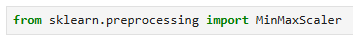

In [15]:
from sklearn.preprocessing import MinMaxScaler

_______________________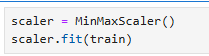

In [16]:
scaler = MinMaxScaler()
scaler.fit(train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


__________________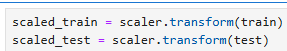

In [17]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [18]:
# Check if the data has been scaled properly
# Print max and min for train and test

# ...
print(scaled_train.max())
print(scaled_test.max())

print(scaled_train.min())
print(scaled_test.min())

1.0
1.0530599939704552
0.0
0.44980403979499545


## Time Series Generator

This class takes in a sequence of data points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.

#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

### We will use 12 months as input and then predict the next month out


_____________________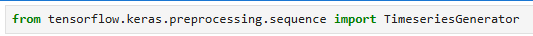

In [19]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [20]:
#TimeseriesGenerator?

_________________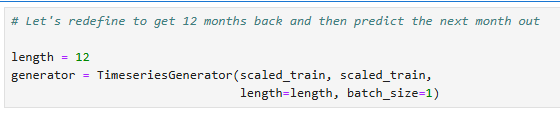

In [21]:
length = 12
generator = TimeseriesGenerator(scaled_train,scaled_train, length = length, batch_size = 1)

_______________________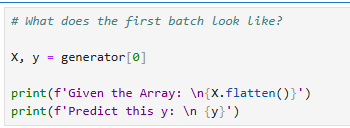

In [22]:
X , y = generator[0]
print(f'Given the Array: \n {X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
 [0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: 
 [[0.12952558]]


### Create the Model

__________________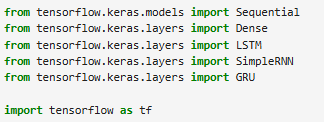

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dropout
import tensorflow as tf

________________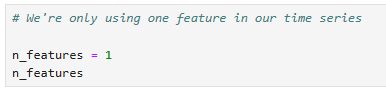

In [24]:
n_features = 1
n_features

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [25]:
model = Sequential()

model.add(GRU(80, input_shape=(length, n_features)))
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\alexq\.conda\envs\Main\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 80)             │        19,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 80)             │        19,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

_____________________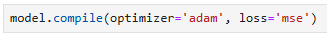

In [27]:
model.compile(optimizer='adam', loss = 'mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.

____________________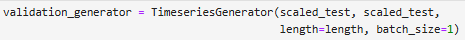

In [28]:
validation_generator= TimeseriesGenerator(scaled_test, scaled_test, length = length, batch_size = 1)

___________________

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 11

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


_____________________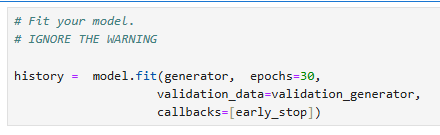

In [31]:
history = model.fit(generator, epochs = 30,
                    validation_data = validation_generator,
                    callbacks = [early_stop])

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0221 - val_loss: 0.0558
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0144 - val_loss: 0.0280
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0137 - val_loss: 0.0459
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0132 - val_loss: 0.0405
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0129 - val_loss: 0.0327
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0124 - val_loss: 0.0718
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0128 - val_loss: 0.0390
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0115 - val_loss: 0.0277
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0113 - val_loss: 0.0167
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0096 - val_loss: 0.0361
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0081 - val_loss: 0.0077
Epoch 12/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

_____________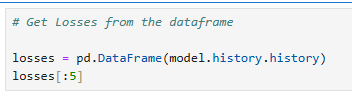

In [32]:
losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.022111,0.055786
1,0.014416,0.028043
2,0.013684,0.045924
3,0.013195,0.040486
4,0.012943,0.032680


In [33]:
# the values may be different


___________________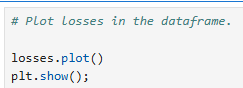

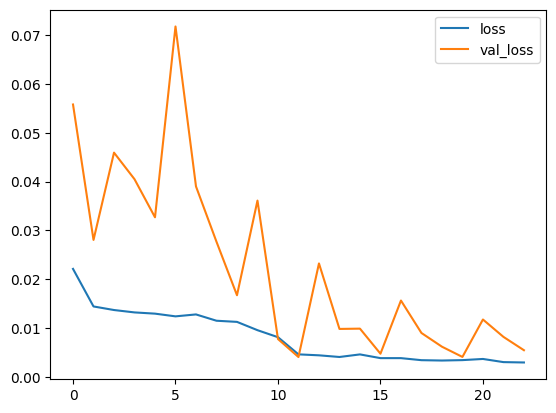

In [34]:
losses.plot()
plt.show();

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

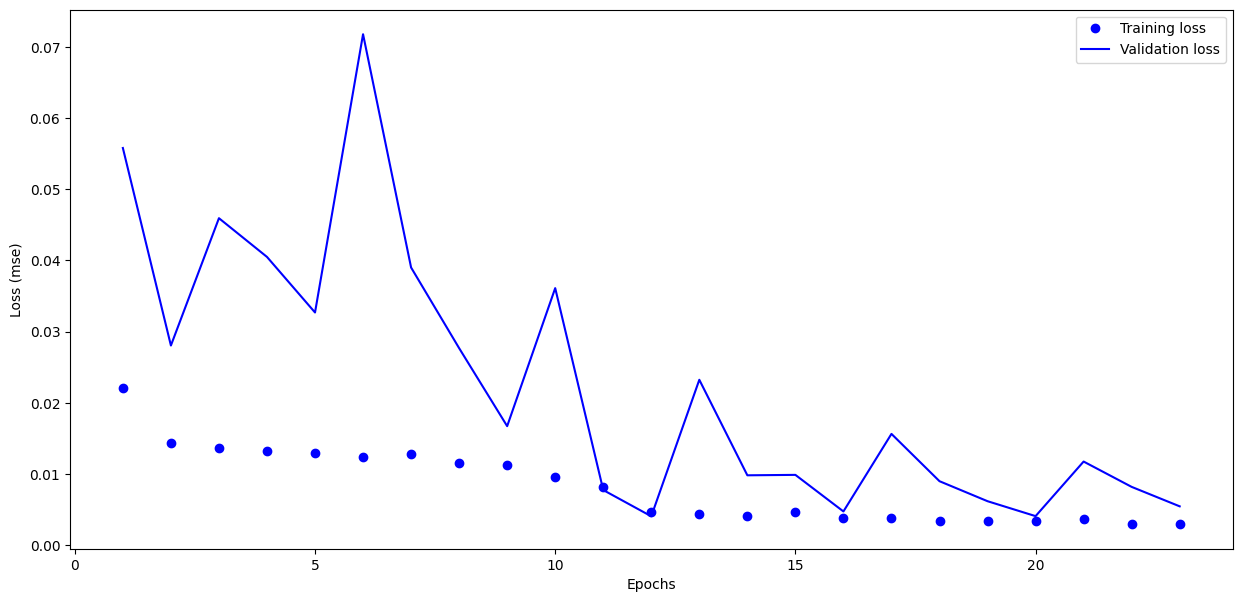

In [35]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

____________________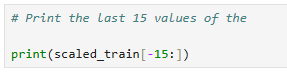

In [36]:
print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


____________________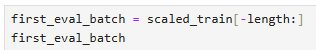

In [37]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [38]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

___________________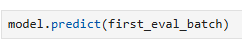

In [39]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


array([[0.59092677]], dtype=float32)

In [40]:
scaled_test[0]

array([0.60665442])

_________________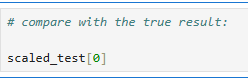

#### Try predicting the series!

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [41]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

____________________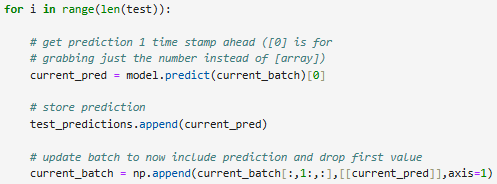

In [42]:
for i in range(len(test)):

    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


______________________

In [43]:
test_predictions

[array([0.59092677], dtype=float32),
 array([0.61576426], dtype=float32),
 array([0.57027215], dtype=float32),
 array([0.57278776], dtype=float32),
 array([0.6821966], dtype=float32),
 array([0.87689704], dtype=float32),
 array([0.5321691], dtype=float32),
 array([0.53569615], dtype=float32),
 array([0.5672099], dtype=float32),
 array([0.5671309], dtype=float32),
 array([0.6143448], dtype=float32),
 array([0.58801645], dtype=float32),
 array([0.5827839], dtype=float32),
 array([0.59988856], dtype=float32),
 array([0.5687593], dtype=float32),
 array([0.55924976], dtype=float32),
 array([0.65848696], dtype=float32),
 array([0.8515581], dtype=float32)]

### Inverse Transformations and Compare

_________________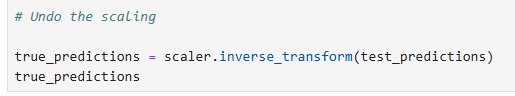

In [44]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[24337.14492548],
       [25243.39056528],
       [23583.51985151],
       [23675.30706072],
       [27667.30796909],
       [34771.34219009],
       [22193.25408387],
       [22321.94538391],
       [23471.78760034],
       [23468.9059974 ],
       [25191.59783012],
       [24230.95622593],
       [24040.0353511 ],
       [24664.13400388],
       [23528.32138789],
       [23181.34594643],
       [26802.21379411],
       [33846.80000269]])

_____________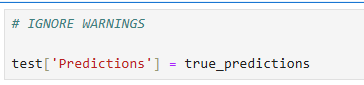

In [45]:
test['Predictions'] = true_predictions

C:\Users\alexq\AppData\Local\Temp\ipykernel_17876\4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [46]:
# Print the test variable

# ...
test

,Sales,Predictions
observation_date,,
2023-07-01,24911,24337.144925
2023-08-01,26657,25243.390565
2023-09-01,23332,23583.519852
2023-10-01,23933,23675.307061
2023-11-01,28580,27667.307969
2023-12-01,40684,34771.342190
2024-01-01,19188,22193.254084
2024-02-01,22005,22321.945384
2024-03-01,24986,23471.787600


### Check and plot predictions

In [47]:
# Print the test variable

# ...
test

,Sales,Predictions
observation_date,,
2023-07-01,24911,24337.144925
2023-08-01,26657,25243.390565
2023-09-01,23332,23583.519852
2023-10-01,23933,23675.307061
2023-11-01,28580,27667.307969
2023-12-01,40684,34771.342190
2024-01-01,19188,22193.254084
2024-02-01,22005,22321.945384
2024-03-01,24986,23471.787600


_______________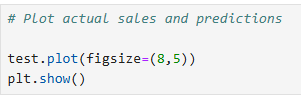

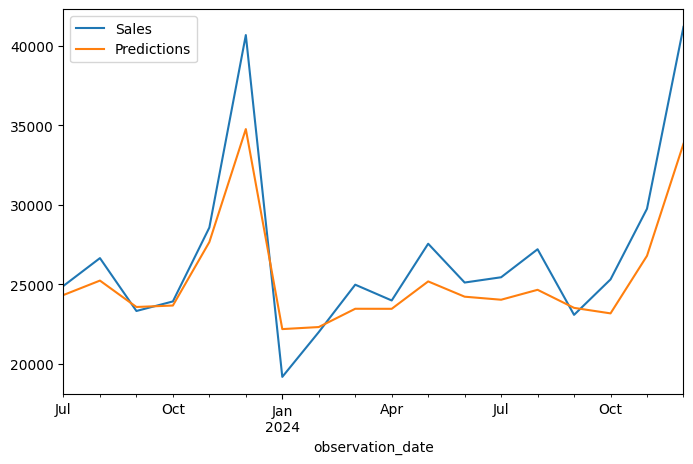

In [48]:
test.plot(figsize=(8,5))
plt.show()

### Retrain and Forecasting

_________________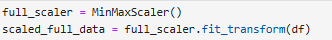

In [49]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

______________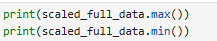

In [50]:
print(scaled_full_data.max())
print(scaled_full_data.min())

1.0
0.0


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [51]:
length = 12 # Length of the output sequences (in number of timesteps)
generator = TimeseriesGenerator(scaled_full_data, 
                                scaled_full_data, length=length, batch_size=1)

In [71]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model
model = Sequential()

model.add(GRU(100, return_sequences=True, input_shape=(length, n_features)))
model.add(GRU(100))
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\alexq\.conda\envs\Main\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 12, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100)            │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,601 (357.82 KB)

 Trainable params: 91,601 (357.82 KB)

 Non-trainable params: 0 (0.00 B)

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [72]:
model.compile(optimizer='adam', loss = 'mse')

In [89]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

#SID 2191871
LAST_DIGIT_IN_YOUR_SID = 11

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


____________________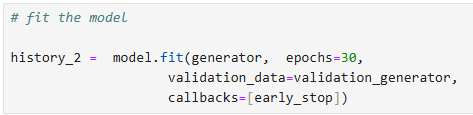

In [74]:
# fit the model

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0187 - val_loss: 0.0301
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0147 - val_loss: 0.0637
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0134 - val_loss: 0.0440
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0139 - val_loss: 0.0452
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0130 - val_loss: 0.0606
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0126 - val_loss: 0.0437
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - val_loss: 0.0358
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0117 - val_loss: 0.0275
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0112 - val_loss: 0.0187
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0055 - val_loss: 0.0063
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0037 - val_loss: 0.0095
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

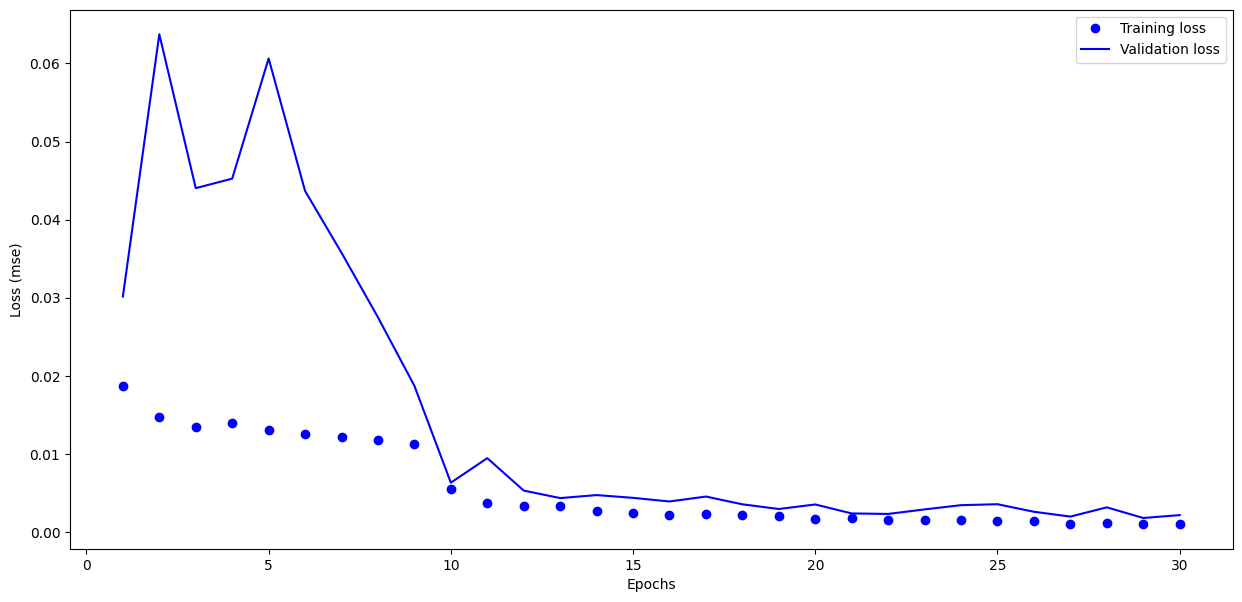

In [91]:
# print Loss for the neural network training process
history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [57]:
# You can use the code created above to type the next cell code

_________________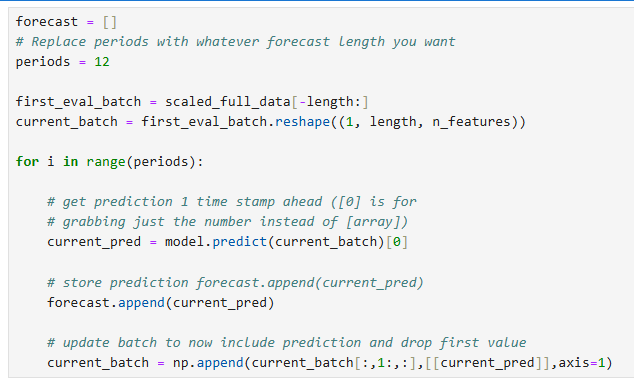

In [76]:
forecast = []
periods = 12

first_eval_batch = scaled_full_data[-length:]           
current_batch = first_eval_batch.reshape((1, length, n_features))  

for i in range(periods):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)

    current_batch = np.append(current_batch[:, 1:, :],[[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


______________________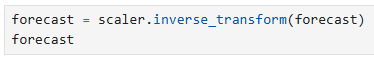

In [77]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[17746.47968644],
       [20399.57695299],
       [23156.3706044 ],
       [22747.97026217],
       [25147.26899028],
       [24593.06606352],
       [24070.8217445 ],
       [24411.51420414],
       [22520.62157655],
       [23555.61941063],
       [27216.3468951 ],
       [36752.84328818]])

### Creating new timestamp index with pandas.

<html> <h4 style="font-style:italic; color:blue;"> Just run the 4 next cells using 'Ctrl' + 'Enter' </h4> </html>

In [78]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

__________________

In [79]:
forecast_index = pd.date_range(start= '2025-01-01', periods=periods,freq='MS')

__________________________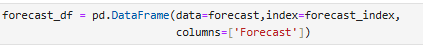

In [80]:
forecast_df = pd.DataFrame(data= forecast, index = forecast_index, columns = ['Forecast'])


________________________

In [81]:
forecast_df

,Forecast
2025-01-01,17746.479686
2025-02-01,20399.576953
2025-03-01,23156.370604
2025-04-01,22747.970262
2025-05-01,25147.268990
2025-06-01,24593.066064
2025-07-01,24070.821745
2025-08-01,24411.514204
2025-09-01,22520.621577
2025-10-01,23555.619411


__________________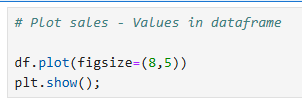

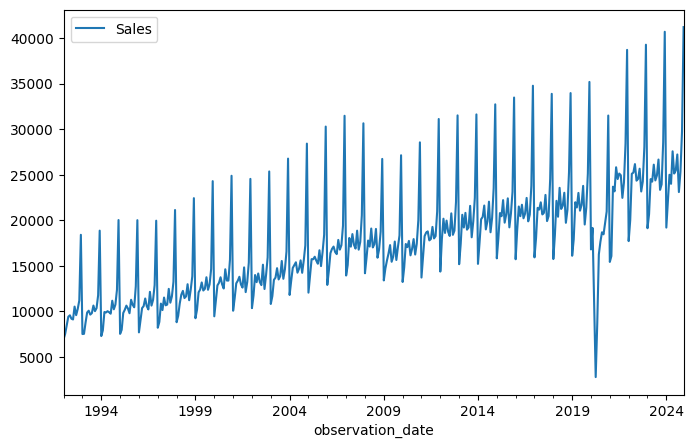

In [82]:
df.plot(figsize=(8,5))
plt.show();

____________________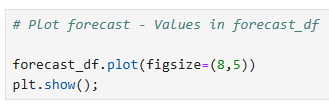

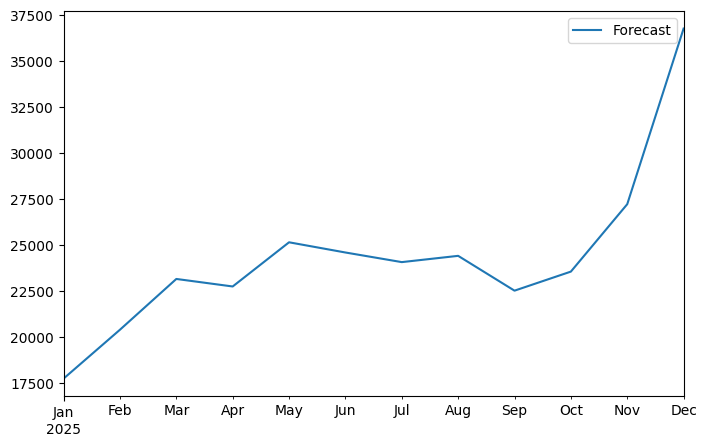

In [83]:
forecast_df.plot(figsize=(8,5))
plt.show();

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

________________________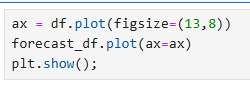

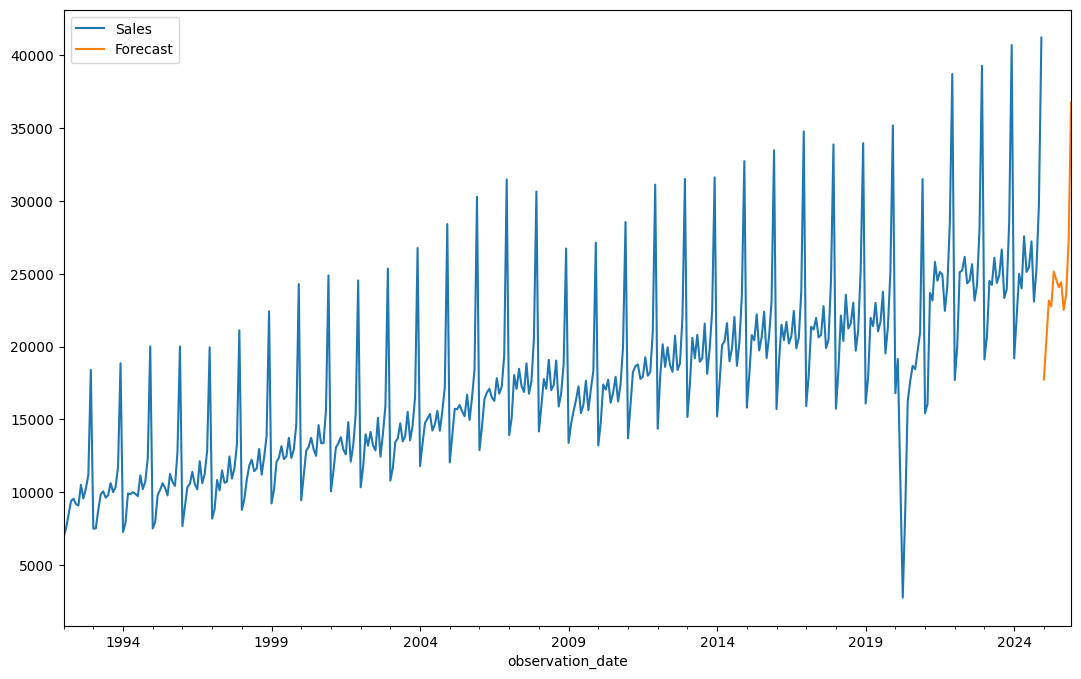

In [84]:
ax = df.plot(figsize=(13,8))
forecast_df.plot(ax=ax)
plt.show();

_______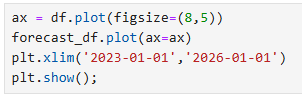

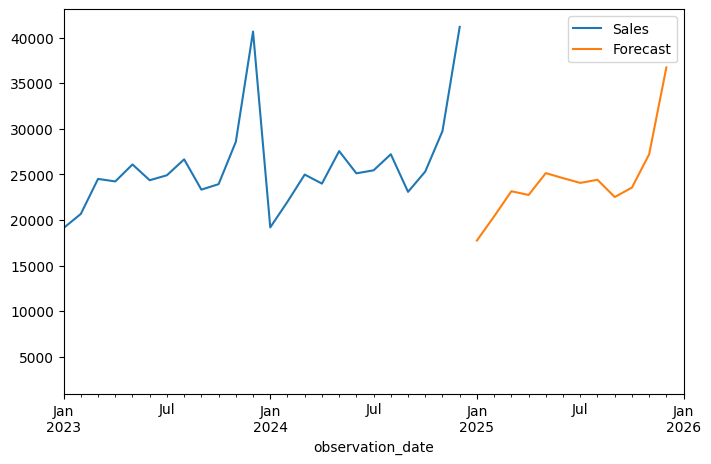

In [85]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01', '2026-01-01')
plt.show()

### Checking Forecast for last 12 months

_______________________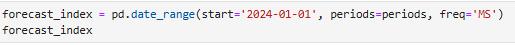

In [86]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods,freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

________________________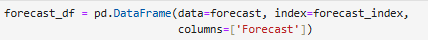

In [87]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,columns=['Forecast'])


___________________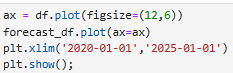

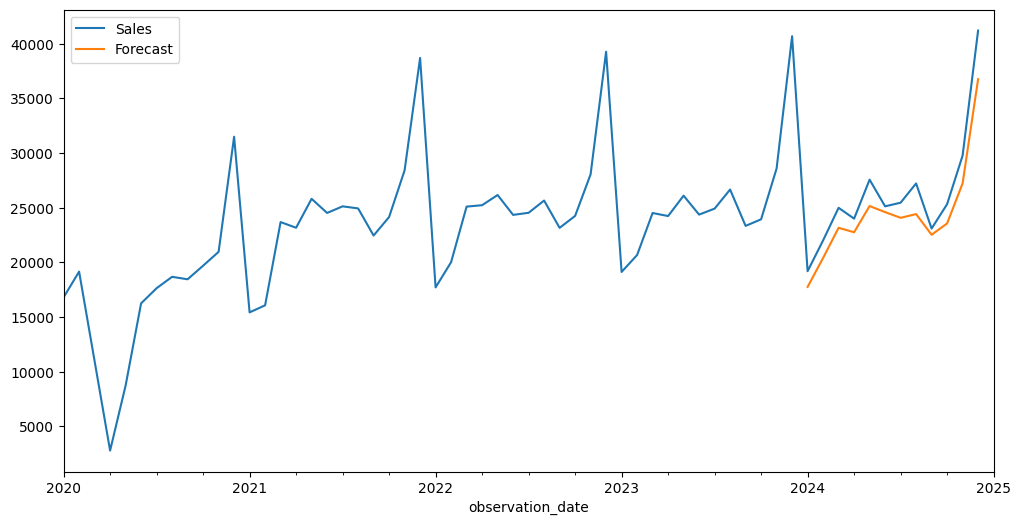

In [88]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show();

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

### Try the same example with a LSTM and/or GRU! (Optional)
Hint: Use LSTM instead of SimpleRNN!

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0206 - val_loss: 0.0510
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0123 - val_loss: 0.0394
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0123 - val_loss: 0.0337
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0119 - val_loss: 0.0430
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0118 - val_loss: 0.0266
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0118 - val_loss: 0.0277
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0115 - val_loss: 0.0409
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0115 - val_loss: 0.0451
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0115 - val_loss: 0.0554
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0115 - val_loss: 0.0531
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0118 - val_loss: 0.0340
Epoch 12/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

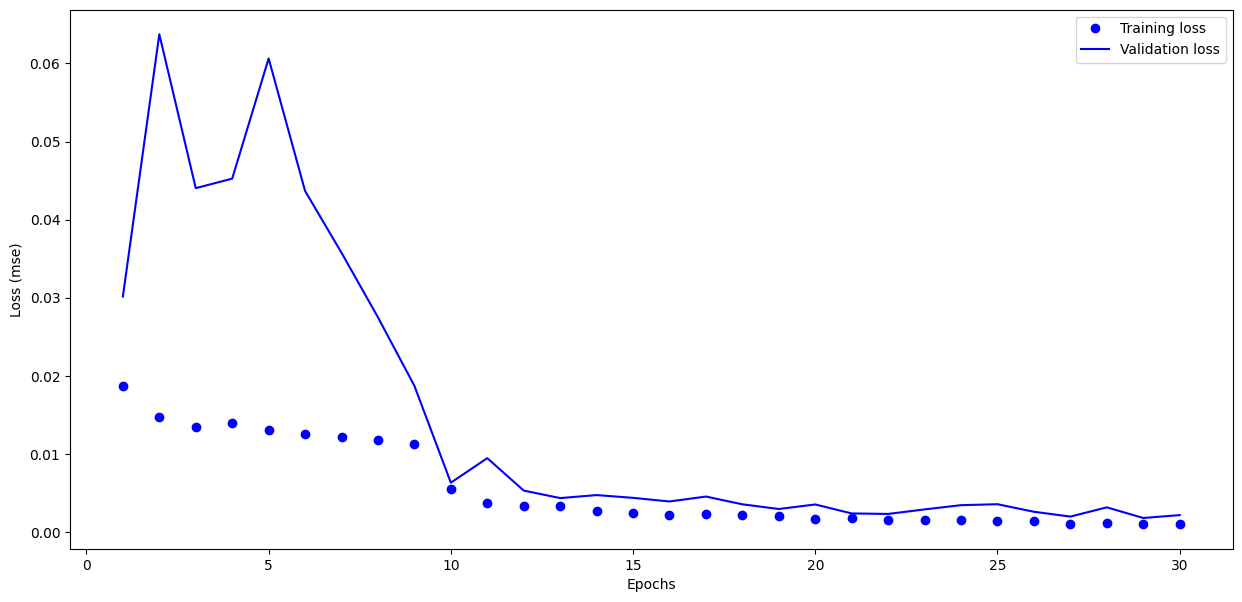

In [93]:
# Use any neural network model based on RNN
# You can also use the model created above
#
# Create the model
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(length, n_features)))
model.add(LSTM(100))
model.add(Dense(1, activation='sigmoid'))

model.summary()


LAST_DIGIT_IN_YOUR_SID = 11
early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)


model.compile(optimizer='adam', loss = 'mse')


# fit the model
history_3 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])


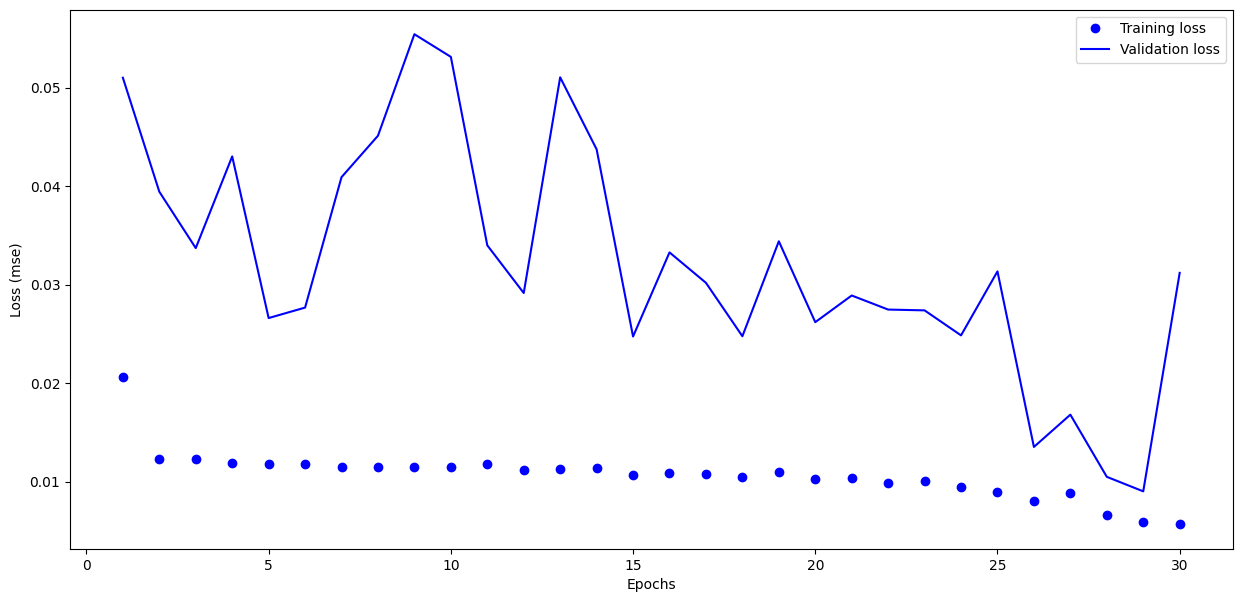

In [95]:
# print Loss for the neural network training process
history_dict = history_3.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()